# Risk Predictor Training Demo
This notebook shows how to create scenario-aware dataloaders for dashcam sequences and verify batch shapes.
It uses the Town10HD holdout split built into `ScenarioSequenceDataset`.

In [12]:
import torch
from torchvision import transforms

from MIREIA.config import Config
from MIREIA.perception.e2e_model import E2EModelConfig, E2ERiskPredictor, Seq2SeqRiskPredictor
from MIREIA.perception.training_utils import (
    build_scenario_dataloaders,
    load_checkpoint,
    save_checkpoint,
    train_model,
 )

In [13]:
model_type = "single"  # "single" or "seq2seq"
m_eval_frames = 5  # used only for seq2seq
seq_len = 5
batch_size = 16
num_workers = 4
prefetch_factor = 2
pin_memory = True

window_subset_ratio = 0.03 # None  # e.g., 0.3 for 30% of windows
window_subset_mode = "random"  # "random" or "first"
window_subset_seed = Config.RANDOM_SEED

# Reuse the default dataset transform
transform = transforms.Compose(
    [
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
    ]
)

train_loader, val_loader, target_mode = build_scenario_dataloaders(
    seq_len=seq_len,
    batch_size=batch_size,
    num_workers=num_workers,
    prefetch_factor=prefetch_factor,
    pin_memory=pin_memory,
    transform=transform,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
    window_subset_ratio=window_subset_ratio,
    window_subset_mode=window_subset_mode,
    window_subset_seed=window_subset_seed,
 )

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 203
Val batches: 41


In [14]:
batch_x, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_x.shape)
print("Batch Y shape:", batch_y.shape)
print("Batch X dtype:", batch_x.dtype)
print("Batch Y dtype:", batch_y.dtype)

Batch X shape: torch.Size([16, 5, 3, 512, 512])
Batch Y shape: torch.Size([16, 1])
Batch X dtype: torch.float32
Batch Y dtype: torch.float32


In [ ]:
import torch
from torch import nn, optim

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch build or check your GPU drivers.")

torch.backends.cudnn.benchmark = True
device = torch.device("cuda")
print(f"Using GPU: {torch.cuda.get_device_name(0)}")

if model_type == "seq2seq":
    model = Seq2SeqRiskPredictor(E2EModelConfig()).to(device)
else:
    model = E2ERiskPredictor(E2EModelConfig()).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
grad_clip = None

epochs = 1
log_every = 25
max_batches_per_epoch = None  # set to an int to cap batches for quicker tests
print(f"Starting training for {epochs} epochs on {device}...")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    criterion=criterion,
    epochs=epochs,
    log_every=log_every,
    max_batches_per_epoch=max_batches_per_epoch,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
    grad_clip=grad_clip,
 )

print("\nTraining complete.")
print(history)

Using GPU: NVIDIA GeForce RTX 4080 SUPER
Starting training for 1 epochs on cuda...
Batch 1/203 | avg loss: 5.899158 | batch shape: (16, 5, 3, 512, 512) | ETA: 883.3s (14.7m)
Batch 25/203 | avg loss: 13.540908 | batch shape: (16, 5, 3, 512, 512) | ETA: 110.3s (1.8m)
Batch 50/203 | avg loss: 11.341033 | batch shape: (16, 5, 3, 512, 512) | ETA: 68.6s (1.1m)
Batch 75/203 | avg loss: 9.550368 | batch shape: (16, 5, 3, 512, 512) | ETA: 49.8s (0.8m)
Batch 100/203 | avg loss: 8.751581 | batch shape: (16, 5, 3, 512, 512) | ETA: 37.1s (0.6m)
Batch 125/203 | avg loss: 8.308793 | batch shape: (16, 5, 3, 512, 512) | ETA: 26.9s (0.4m)


In [ ]:
import os

checkpoint_path = os.path.join(
    Config.PATH_TO_MODELS,
    f"{model_type}_checkpoint.pt",
)

save_checkpoint(
    checkpoint_path=checkpoint_path,
    model=model,
    optimizer=optimizer,
    history=history,
    epoch=epochs,
    extra={
        "model_type": model_type,
        "m_eval_frames": m_eval_frames,
        "target_mode": target_mode,
    },
)
print(f"Checkpoint saved to {checkpoint_path}")

Checkpoint saved to e2e_checkpoint.pt


In [ ]:
# Resume training from checkpoint if available
import os
import torch
from torch import nn, optim

resume_epochs = 3 # number of epochs to train after resuming

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch build or check your GPU drivers.")

device = torch.device("cuda")
if model_type == "seq2seq":
    model = Seq2SeqRiskPredictor(E2EModelConfig()).to(device)
else:
    model = E2ERiskPredictor(E2EModelConfig()).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

start_epoch = 5
history = {"train_loss": [], "val_loss": []}
if os.path.exists(checkpoint_path):
    ckpt = load_checkpoint(checkpoint_path, model, optimizer=optimizer, device=device)
    history = ckpt.get("history", history)
    start_epoch = ckpt.get("epoch", 0) + 1
    model_type = ckpt.get("model_type", model_type)
    m_eval_frames = ckpt.get("m_eval_frames", m_eval_frames)
    print(f"Resuming from {checkpoint_path} at epoch {start_epoch}")
else:
    print("No checkpoint found. Starting fresh.")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    criterion=criterion,
    epochs=resume_epochs,
    start_epoch=start_epoch,
    history=history,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
 )

save_checkpoint(
    checkpoint_path=checkpoint_path,
    model=model,
    optimizer=optimizer,
    history=history,
    epoch=start_epoch + resume_epochs - 1,
    extra={
        "model_type": model_type,
        "m_eval_frames": m_eval_frames,
        "target_mode": target_mode,
    },
)
print(f"Saved checkpoint: {checkpoint_path}")

C:\Users\mique\AppData\Local\Temp\ipykernel_3684\2879302497.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=device)


Resuming from e2e_checkpoint.pt at epoch 6

Resume Epoch 6
Train loss: 0.546797
Val loss:   4.734090
Saved checkpoint: e2e_checkpoint.pt

Resume Epoch 7
Train loss: 0.334371
Val loss:   1.931590
Saved checkpoint: e2e_checkpoint.pt

Resume Epoch 8
Train loss: 0.214607
Val loss:   2.010121
Saved checkpoint: e2e_checkpoint.pt


In [ ]:
# Summary metrics (run after training)
train_samples = len(train_loader.dataset)
val_samples = len(val_loader.dataset) if val_loader is not None else 0
print(f"Train samples: {train_samples}")
print(f"Val samples:   {val_samples}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

if "history" in globals() and history.get("train_loss"):
    best_train = min(history["train_loss"])
    print(f"Best train loss: {best_train:.6f}")
if "history" in globals() and history.get("val_loss"):
    best_val = min(history["val_loss"])
    print(f"Best val loss:   {best_val:.6f}")

Train samples: 93816
Val samples:   14448
Train batches: 7818
Val batches:   1204
Best train loss: 3.765158
Best val loss:   10.764936


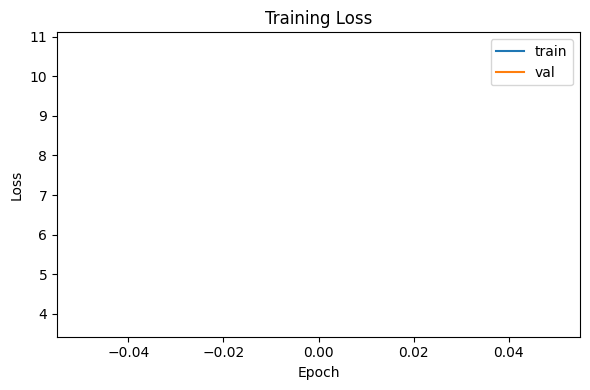

In [ ]:
import matplotlib.pyplot as plt

if "history" in globals() and history.get("train_loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    if history.get("val_loss"):
        plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history found. Run the training cell first.")

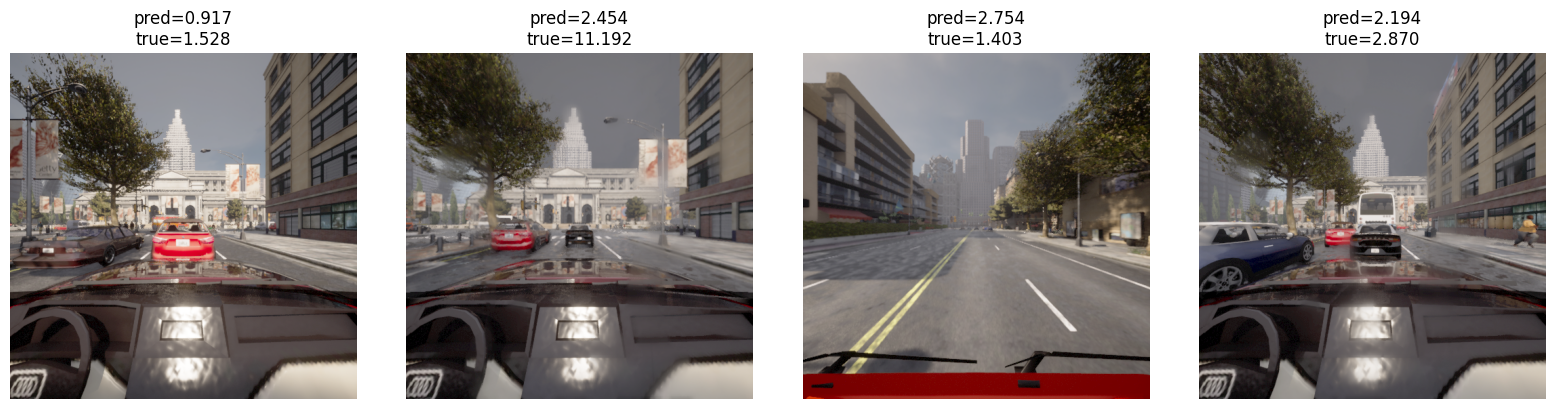

In [ ]:
import matplotlib.pyplot as plt
import torch
import random

if "model" not in globals():
    print("Model not found. Run the training cell first.")
else:
    model.eval()
    dataset = val_loader.dataset if val_loader is not None else train_loader.dataset
    n_show = 4
    rng = random.Random(Config.RANDOM_SEED)
    indices = rng.sample(range(len(dataset)), k=min(n_show, len(dataset)))
    sequences = [dataset[idx] for idx in indices]
    batch_x = torch.stack([seq for seq, _ in sequences], dim=0)
    batch_y = torch.stack([target for _, target in sequences], dim=0)
    with torch.no_grad():
        if model_type == "seq2seq":
            preds = model(batch_x.to(device, non_blocking=True), m_eval_frames=m_eval_frames).cpu()
            pred_vals = preds[:, -1, 0] if preds.ndim == 3 else preds.squeeze(1)
        else:
            preds = model(batch_x.to(device, non_blocking=True)).cpu().squeeze(1)
            pred_vals = preds
    if batch_y.ndim == 3:
        target_vals = batch_y[:, -1, 0]
    else:
        target_vals = batch_y.squeeze(1)
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for i in range(len(indices)):
        frame0 = batch_x[i, 0].permute(1, 2, 0).cpu()
        axes[i].imshow(frame0)
        axes[i].axis("off")
        axes[i].set_title(f"pred={pred_vals[i]:.3f}\ntrue={target_vals[i]:.3f}")
    plt.tight_layout()
    plt.show()